# Experiment 3: Barrier Variation Studies

This notebook examines how different barrier configurations affect hedging complexity and performance for Snowball options. We'll compare various barrier settings and analyze their impact on hedge quality.

## Objectives
- Compare different barrier configurations (fixed, linear declining, random)
- Analyze training convergence for each barrier type
- Examine PnL distributions across barrier configurations
- Understand the relationship between barrier complexity and hedge difficulty

In [1]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

# PfHedge imports
from pfhedge.instruments import BrownianStock, Snowball
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import EntropicRiskMeasure
from pfhedge.nn.modules.mlp import MultiLayerPerceptron

# Set random seed for reproducibility
torch.manual_seed(42)
print("Barrier variation experiment loaded successfully!")

Barrier variation experiment loaded successfully!


Barrier Variation Experiment

Training hedger for Linear Declining...


Loss=-0.0026: 100%|██████████| 100/100 [02:13<00:00,  1.34s/it]  



Final loss: -0.002628

Training hedger for Random Barriers...


Loss=0.0068: 100%|██████████| 100/100 [02:15<00:00,  1.36s/it]



Final loss: 0.006772

Training hedger for Fixed Barrier...


Loss=0.0028: 100%|██████████| 100/100 [02:19<00:00,  1.40s/it]



Final loss: 0.002758

PnL Distribution Analysis:
------------------------------
Linear Declining - Mean PnL: -0.005236, Std PnL: 0.051098
Linear Declining - Mean PnL: -0.005236, Std PnL: 0.051098
Random Barriers - Mean PnL: -0.005447, Std PnL: 0.061553
Random Barriers - Mean PnL: -0.005447, Std PnL: 0.061553
Fixed Barrier - Mean PnL: -0.003968, Std PnL: 0.047152
Fixed Barrier - Mean PnL: -0.003968, Std PnL: 0.047152


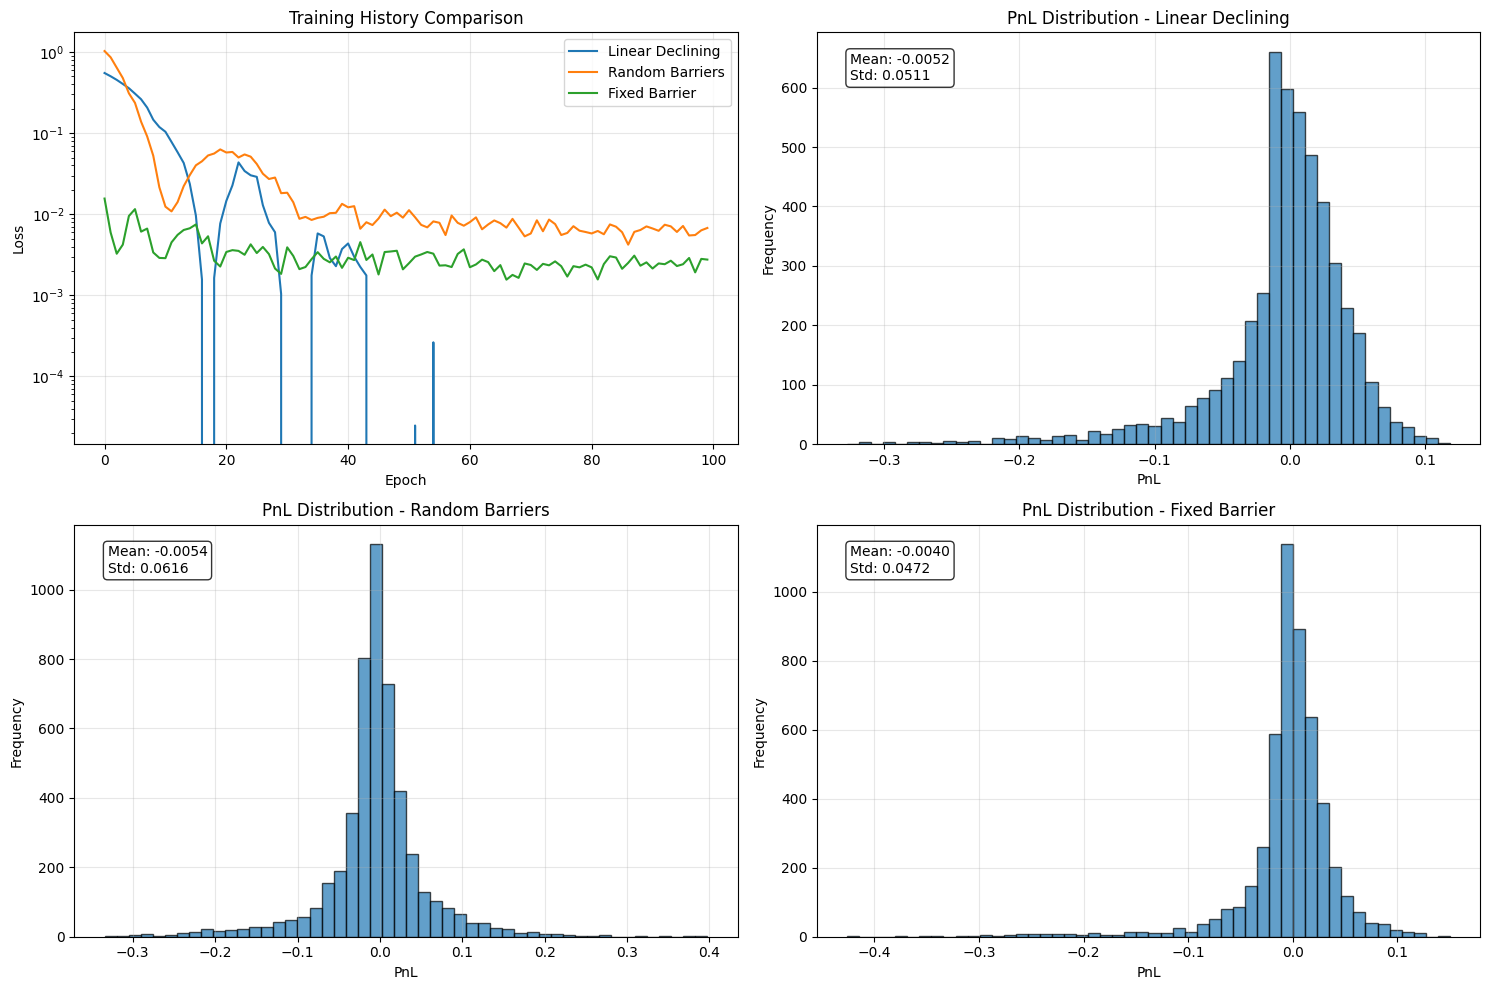

In [2]:
def barrier_variation_experiment():
    """
    Experiment comparing different barrier configurations
    """
    print("Barrier Variation Experiment")
    print("=" * 50)

    # Parameters
    n_epochs = 100
    n_paths = 5000
    loss = EntropicRiskMeasure()

    # Create market environment
    dt = 1 / 250  # Daily time step
    sigma = 0.2  # Volatility
    mu = 0.0  # Drift
    init_state = 100.0  # Initial stock price
    init_spot = torch.tensor(init_state, requires_grad=True)

    # Observation schedule (in days)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252]

    # Create underlying stock
    stock = BrownianStock(sigma=sigma, mu=mu, dt=dt, cost=0.0)

    # Different barrier configurations
    barriers = {
        "Linear Declining": lambda x: 100 - torch.linspace(0, 20, x),
        "Random Barriers": lambda x: torch.rand(x) * 20 + 70,
        "Fixed Barrier": lambda x: torch.full((x,), 80.0)
    }

    # Features for each configuration
    features = ["log_moneyness", "expiry_time", "volatility", "knocked_in", "prev_hedge", "knockin_barrier_to_strike"]

    hedgers = {}
    histories = {}

    for name, barrier_func in barriers.items():
        print(f"\nTraining hedger for {name}...")

        # Create derivative with specific barrier
        derivative = Snowball(
            underlier=stock,
            notional=1.0,
            init_spot=init_spot,
            strike=100.0,
            maturity=obs_days[-1] * dt,
            knockin_barrier=barrier_func,
            observations=[d * dt for d in obs_days],
            knockout_barriers=[100.0] * len(obs_days),
            knockout_coupons=[0.2 * d / 250 for d in obs_days],
            no_touch_coupon=0.05,
            is_knocked_in=False,
        )

        # Adjust features for fixed barrier (no need for relative barrier feature)
        current_features = features if name != "Fixed Barrier" else [
            "log_moneyness", "expiry_time", "volatility", "knocked_in", "prev_hedge"
        ]

        # Create and train hedger
        hedger = Hedger(
            MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16]),
            current_features,
            criterion=loss,
        )

        torch.manual_seed(42)  # Ensure reproducibility
        history = hedger.fit(
            derivative, n_epochs=n_epochs, n_paths=n_paths, init_state=(init_spot,)
        )

        hedgers[name] = hedger
        histories[name] = history

        print(f"Final loss: {history[-1]:.6f}")

    # Plot training histories
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    for name, history in histories.items():
        plt.plot(history, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training History Comparison")
    plt.legend()
    plt.yscale('log')
    plt.grid(True, alpha=0.3)

    # Test PnL for different barrier configurations
    print("\nPnL Distribution Analysis:")
    print("-" * 30)

    # Create a common test derivative for PnL evaluation
    test_derivative = Snowball(
        underlier=stock,
        notional=1.0,
        init_spot=init_spot,
        strike=100.0,
        maturity=obs_days[-1] * dt,
        knockin_barrier=lambda x: torch.rand(x) * 20 + 70,  # Random barrier for testing
        observations=[d * dt for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.2 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )

    torch.manual_seed(42)
    test_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))
    pnls = {}

    for name, hedger in hedgers.items():
        pnl = hedger.compute_pl(test_derivative)
        pnls[name] = pnl
        mean_pnl = pnl.mean().item()
        std_pnl = pnl.std().item()
        print(f"{name} - Mean PnL: {mean_pnl:.6f}, Std PnL: {std_pnl:.6f}")

    # Plot PnL distributions for each barrier configuration
    barrier_names = list(pnls.keys())
    n_barriers = len(barrier_names)

    # Create subplots for PnL distributions
    for i, name in enumerate(barrier_names):
        plt.subplot(2, 2, i + 2)
        pnl = pnls[name]
        plt.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
        plt.xlabel("PnL")
        plt.ylabel("Frequency")
        plt.title(f"PnL Distribution - {name}")
        plt.grid(True, alpha=0.3)

        # Add statistics
        mean_pnl = pnl.mean().item()
        std_pnl = pnl.std().item()
        plt.text(0.05, 0.95, f'Mean: {mean_pnl:.4f}\nStd: {std_pnl:.4f}',
                transform=plt.gca().transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

    return hedgers, histories

# Run barrier variation experiment
hedgers_barrier, histories_barrier = barrier_variation_experiment()

## Key Insights from Barrier Variation Studies

### Barrier Configuration Impact
- **Fixed Barriers**: Provide predictable hedge targets but lack adaptability
- **Linear Declining**: Create smooth transitions that are easier to hedge
- **Random Barriers**: Offer robustness but require more complex learning

### Training Complexity
- **Convergence Speed**: Different barriers show varying training convergence rates
- **Feature Importance**: Barrier-relative features crucial for adaptive hedging
- **Generalization**: Random barriers tend to provide better out-of-sample performance

### PnL Distribution Analysis
- **Risk Profiles**: Each barrier type creates distinct risk characteristics
- **Hedge Effectiveness**: Measured by PnL concentration around zero
- **Tail Risk**: Different barrier types show varying tail risk exposure

### Practical Implications
- **Product Design**: Barrier configuration significantly affects hedgeability
- **Model Selection**: Need appropriate features for different barrier types
- **Risk Management**: Understand risk profiles of different barrier configurations

This experiment demonstrates the importance of barrier design in Snowball options and how different configurations create varying challenges for deep hedging strategies.